# Notebook 2 — Benchmark Frozen Pretrained CNN Models

This notebook compares several ImageNet-pretrained convolutional neural networks as frozen feature extractors on the binary restricted-dog dataset created by Notebook 1.

Use a **GPU runtime**. A T4 is suitable.

Dataset:

```text
/content/drive/MyDrive/restricted-dog-cnn/data
```

Outputs:

```text
/content/drive/MyDrive/restricted-dog-cnn/model_zoo
```

The confusion matrices are displayed and duplicated as numerical tables.


In [ ]:
# ============================================================
# 0. Mount Google Drive and define project paths
# ============================================================
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

PROJECT_FOLDER_NAME = "restricted-dog-cnn"
PROJECT_ROOT = Path("/content/drive/MyDrive") / PROJECT_FOLDER_NAME

DATA_DIR = PROJECT_ROOT / "data"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

MODEL_ROOT = PROJECT_ROOT / "model_zoo"
CHECKPOINT_DIR = MODEL_ROOT / "checkpoints"
LOG_DIR = MODEL_ROOT / "logs"
FIGURE_DIR = MODEL_ROOT / "figures"
PREDICTION_DIR = MODEL_ROOT / "predictions"

for folder in [
    MODEL_ROOT,
    CHECKPOINT_DIR,
    LOG_DIR,
    FIGURE_DIR,
    PREDICTION_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data folder: ", DATA_DIR)
print("Outputs:     ", MODEL_ROOT)


Mounted at /content/drive
Project root: /content/drive/MyDrive/restricted-dog-computer-vision
Data folder:  /content/drive/MyDrive/restricted-dog-computer-vision/data
Outputs:      /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo


In [ ]:
# ============================================================
# 1. Verify that Notebook 1 completed correctly
# ============================================================
from pathlib import Path

CLASS_NAMES = ["unrestricted", "restricted"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}


def count_images(folder: Path) -> int:
    if not folder.exists():
        return 0
    return sum(1 for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)


required_folders = []
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for class_name in CLASS_NAMES:
        required_folders.append(split_dir / class_name)

print("=" * 70)
print("DATASET VERIFICATION")
print("=" * 70)

missing_or_empty = []
counts = {}

for folder in required_folders:
    n = count_images(folder)
    counts[str(folder)] = n
    status = "OK" if folder.exists() and n > 0 else "MISSING/EMPTY"
    print(f"{status:14s} {folder}: {n} images")
    if not folder.exists() or n == 0:
        missing_or_empty.append(folder)

print("=" * 70)

if missing_or_empty:
    raise FileNotFoundError(
        "Notebook 1 has not produced a complete dataset split.\n"
        "Run Notebook 1 first, then rerun Notebook 2.\n\n"
        "Missing or empty folders:\n" + "\n".join(str(p) for p in missing_or_empty)
    )

print("Dataset split is complete.")
print("Class order is fixed as:")
print("0 = unrestricted")
print("1 = restricted")


DATASET VERIFICATION
OK             /content/drive/MyDrive/restricted-dog-computer-vision/data/train/unrestricted: 2462 images
OK             /content/drive/MyDrive/restricted-dog-computer-vision/data/train/restricted: 561 images
OK             /content/drive/MyDrive/restricted-dog-computer-vision/data/val/unrestricted: 816 images
OK             /content/drive/MyDrive/restricted-dog-computer-vision/data/val/restricted: 186 images
OK             /content/drive/MyDrive/restricted-dog-computer-vision/data/test/unrestricted: 838 images
OK             /content/drive/MyDrive/restricted-dog-computer-vision/data/test/restricted: 190 images
Dataset split is complete.
Class order is fixed as:
0 = unrestricted
1 = restricted


In [ ]:
# ============================================================
# 2. Verify GPU: Notebook 2 should use a T4 or other GPU
# ============================================================
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    raise RuntimeError(
        "No GPU detected. For Notebook 2, use: Runtime -> Change runtime type -> T4 GPU."
    )

print("GPU detected:")
for gpu in gpus:
    print(" -", gpu)

# Avoid TensorFlow grabbing all GPU memory at once when possible.
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Could not set memory growth for", gpu, "because:", e)


TensorFlow version: 2.20.0
GPU detected:
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
# ============================================================
# 3. Imports and core configuration
# ============================================================
import json
import random
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
)

from tensorflow.keras import layers

SEED = 58
BATCH_SIZE = 8
EPOCHS = 20
PATIENCE = 4
LEARNING_RATE = 1e-4
THRESHOLD = 0.5

# Keep this small while debugging. After one clean run, add more models.
TO_RUN = [
    "VGG16",
    "ResNet50",
    "InceptionV3",
    "Xception",
    "InceptionResNetV2",
    "NASNetMobile",
]


# TO_RUN = [
#     "InceptionResNetV2",
#     "NASNetMobile",
# ]


random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configuration")
print("Seed:", SEED)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Threshold:", THRESHOLD)
print("Models to run:", TO_RUN)


Configuration
Seed: 58
Batch size: 8
Epochs: 20
Patience: 4
Learning rate: 0.0001
Threshold: 0.5
Models to run: ['VGG16', 'ResNet50', 'InceptionV3', 'Xception', 'InceptionResNetV2', 'NASNetMobile']


In [ ]:
# ============================================================
# 4. Compute class weights from training folder counts
# ============================================================

def count_images(folder: Path) -> int:
    exts = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
    return sum(1 for p in folder.rglob("*") if p.suffix in exts)

n_unrestricted = count_images(TRAIN_DIR / "unrestricted")
n_restricted = count_images(TRAIN_DIR / "restricted")
n_total = n_unrestricted + n_restricted

if n_unrestricted == 0 or n_restricted == 0:
    raise RuntimeError(
        f"Training folders must contain both classes. "
        f"Found unrestricted={n_unrestricted}, restricted={n_restricted}"
    )

CLASS_WEIGHT = {
    0: n_total / (2 * n_unrestricted),
    1: n_total / (2 * n_restricted),
}

print("Training counts")
print("Unrestricted:", n_unrestricted)
print("Restricted:  ", n_restricted)
print("Total:       ", n_total)
print("Class weight:", CLASS_WEIGHT)

Training counts
Unrestricted: 2462
Restricted:   561
Total:        3023
Class weight: {0: 0.613931762794476, 1: 2.694295900178253}


In [ ]:
from pathlib import Path

ROOT = DATA_DIR

for split in ["train", "val", "test"]:
    print("\n", split.upper())

    for cls in ["unrestricted", "restricted"]:
        p = ROOT / split / cls

        print(f"{cls}:")
        print("  Exists:", p.exists())

        if p.exists():
            files = list(p.glob("*.jpg"))
            print("  JPG count:", len(files))


 TRAIN
unrestricted:
  Exists: True
  JPG count: 2462
restricted:
  Exists: True
  JPG count: 561

 VAL
unrestricted:
  Exists: True
  JPG count: 816
restricted:
  Exists: True
  JPG count: 186

 TEST
unrestricted:
  Exists: True
  JPG count: 838
restricted:
  Exists: True
  JPG count: 190


In [ ]:
# ============================================================
# 5. Dataset loader
# ============================================================
AUTOTUNE = tf.data.AUTOTUNE


def make_raw_dataset(directory: Path, image_size: tuple[int, int], shuffle: bool):
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="binary",
        class_names=CLASS_NAMES,
        image_size=image_size,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED if shuffle else None,
    )


def make_datasets(image_size: tuple[int, int]):
    train_ds = make_raw_dataset(TRAIN_DIR, image_size=image_size, shuffle=True)
    val_ds = make_raw_dataset(VAL_DIR, image_size=image_size, shuffle=False)
    test_ds = make_raw_dataset(TEST_DIR, image_size=image_size, shuffle=False)

    # Do not cache here. Avoid stale cache or memory pressure when changing model input sizes.
    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds = val_ds.prefetch(AUTOTUNE)
    test_ds = test_ds.prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds


print("Dataset loader ready.")
print("Class names:", CLASS_NAMES)


Dataset loader ready.
Class names: ['unrestricted', 'restricted']


In [ ]:
# ============================================================
# 6. Model registry
# ============================================================
from tensorflow.keras.applications import (
    vgg16,
    resnet50,
    inception_v3,
    xception,
    inception_resnet_v2,
    nasnet,
)

MODEL_ZOO = {
    "VGG16": {
        "constructor": vgg16.VGG16,
        "preprocess": vgg16.preprocess_input,
        "input_size": (224, 224),
    },
    "ResNet50": {
        "constructor": resnet50.ResNet50,
        "preprocess": resnet50.preprocess_input,
        "input_size": (224, 224),
    },
    "InceptionV3": {
        "constructor": inception_v3.InceptionV3,
        "preprocess": inception_v3.preprocess_input,
        "input_size": (299, 299),
    },
    "Xception": {
        "constructor": xception.Xception,
        "preprocess": xception.preprocess_input,
        "input_size": (299, 299),
    },
    "InceptionResNetV2": {
        "constructor": inception_resnet_v2.InceptionResNetV2,
        "preprocess": inception_resnet_v2.preprocess_input,
        "input_size": (299, 299),
    },
    "NASNetMobile": {
        "constructor": nasnet.NASNetMobile,
        "preprocess": nasnet.preprocess_input,
        "input_size": (224, 224),
    },
}

unknown = [name for name in TO_RUN if name not in MODEL_ZOO]
if unknown:
    raise ValueError(f"Unknown model names in TO_RUN: {unknown}")

print("Model registry ready.")
for name in TO_RUN:
    print(f"{name:20s} input_size={MODEL_ZOO[name]['input_size']}")


Model registry ready.
VGG16                input_size=(224, 224)
ResNet50             input_size=(224, 224)
InceptionV3          input_size=(299, 299)
Xception             input_size=(299, 299)
InceptionResNetV2    input_size=(299, 299)
NASNetMobile         input_size=(224, 224)


In [ ]:
# ============================================================
# 7. Build frozen transfer-learning model
# ============================================================
def build_frozen_model(model_name: str) -> tf.keras.Model:
    spec = MODEL_ZOO[model_name]
    constructor = spec["constructor"]
    preprocess = spec["preprocess"]
    input_size = spec["input_size"]

    base_model = constructor(
        include_top=False,
        weights="imagenet",
        input_shape=(*input_size, 3),
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(*input_size, 3), name="image")

    # Light augmentation is included inside the model so it is saved with the model graph.
    x = layers.RandomFlip("horizontal", name="aug_flip")(inputs)
    x = layers.RandomRotation(0.05, name="aug_rotation")(x)
    x = layers.RandomZoom(0.10, name="aug_zoom")(x)

    x = preprocess(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dropout(0.20, name="dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="restricted_probability")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=f"{model_name}_frozen")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=THRESHOLD),
            tf.keras.metrics.Precision(name="precision", thresholds=THRESHOLD),
            tf.keras.metrics.Recall(name="recall", thresholds=THRESHOLD),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        ],
    )

    return model


print("Model builder ready.")


Model builder ready.


In [ ]:
# ============================================================
# 8. Callback factory
# ============================================================
def make_callbacks(model_name: str):
    checkpoint_path = CHECKPOINT_DIR / f"{model_name}_best.keras"
    csv_log_path = LOG_DIR / f"{model_name}_training_log.csv"

    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(str(csv_log_path), append=False),
    ]


print("Callbacks ready.")


Callbacks ready.


In [ ]:
# ============================================================
# 9. Helper functions for evaluation and plots
# ============================================================

def collect_predictions(model: tf.keras.Model, dataset):
    y_true = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0).reshape(-1)

        y_prob.extend(probs.tolist())

        y_true.extend(
            labels.numpy()
            .reshape(-1)
            .astype(int)
            .tolist()
        )

    return (
        np.array(y_true, dtype=int),
        np.array(y_prob, dtype=float),
    )


def compute_metrics(
    y_true,
    y_prob,
    threshold: float = THRESHOLD,
) -> dict:

    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    tn, fp, fn, tp = cm.ravel()

    output = {
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "mcc": matthews_corrcoef(
            y_true,
            y_pred,
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

    # AUC metrics require both classes to be present.
    if len(np.unique(y_true)) == 2:
        output["auc"] = roc_auc_score(
            y_true,
            y_prob,
        )

        output["pr_auc"] = average_precision_score(
            y_true,
            y_prob,
        )

    else:
        output["auc"] = np.nan
        output["pr_auc"] = np.nan

    return output


def save_learning_curve(
    history: dict,
    model_name: str,
):

    epochs = range(
        1,
        len(history["loss"]) + 1,
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        history["accuracy"],
        label="Train accuracy",
    )

    plt.plot(
        epochs,
        history["val_accuracy"],
        label="Validation accuracy",
    )

    plt.plot(
        epochs,
        history["loss"],
        label="Train loss",
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation loss",
    )

    plt.title(
        f"{model_name} Learning Curves"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Metric / Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    out_path = (
        FIGURE_DIR
        / f"{model_name}_learning_curves.png"
    )

    plt.savefig(
        out_path,
        dpi=300,
        facecolor="white",
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    return out_path


def save_confusion_matrix_plot(
    y_true,
    y_prob,
    model_name,
    threshold: float = THRESHOLD,
):

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    labels = [
        "Unrestricted",
        "Restricted",
    ]

    # --------------------------------------------------------
    # Blue graphical confusion matrix
    # --------------------------------------------------------

    plt.figure(figsize=(7, 6))

    im = plt.imshow(
        cm,
        cmap="Blues",
    )

    plt.colorbar(im)

    plt.title(
        f"{model_name} Confusion Matrix",
        fontsize=18,
        pad=16,
    )

    plt.xlabel(
        "Predicted class",
        fontsize=14,
    )

    plt.ylabel(
        "True class",
        fontsize=14,
    )

    plt.xticks(
        [0, 1],
        labels,
        fontsize=12,
    )

    plt.yticks(
        [0, 1],
        labels,
        fontsize=12,
    )

    max_value = cm.max()

    for i in range(2):
        for j in range(2):

            value = cm[i, j]

            text_color = (
                "white"
                if value > max_value / 2
                else "black"
            )

            plt.text(
                j,
                i,
                str(value),
                ha="center",
                va="center",
                fontsize=18,
                fontweight="bold",
                color=text_color,
            )

    plt.tight_layout()

    out_path = (
        FIGURE_DIR
        / f"{model_name}_confusion_matrix.png"
    )

    plt.savefig(
        out_path,
        dpi=300,
        facecolor="white",
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    # --------------------------------------------------------
    # Plain numerical confusion-matrix table
    # --------------------------------------------------------

    cm_table = pd.DataFrame(
        cm,
        index=[
            "True unrestricted",
            "True restricted",
        ],
        columns=[
            "Predicted unrestricted",
            "Predicted restricted",
        ],
    )

    print(
        f"\n{model_name} confusion matrix as a table:"
    )

    display(cm_table)

    return out_path


print("Evaluation helpers ready.")

Evaluation helpers ready.


No previous results file found. Starting fresh.

TRAINING VGG16
Input size: (224, 224)
Found 3023 files belonging to 2 classes.
Found 1002 files belonging to 2 classes.
Found 1028 files belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 parameters: 14,715,201
Epoch 1/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5481 - auc: 0.5396 - loss: 2.4576 - pr_auc: 0.2076 - precision: 0.2056 - recall: 0.4926
Epoch 1: val_loss improved from None to 1.73608, saving model to /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/VGG16_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/VGG16_best.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 679s 2s/step - accuracy: 0.5409 - auc: 0.5544 - loss: 2.3429 - pr_auc: 0.2114 - precision: 0.2057 - recall: 0.5152 - val_accuracy: 0.6307 - val_auc: 0.6580 - val_loss: 1.7361 - val_pr_auc: 0.2924 - val_precision: 0.2799 - val_recall: 0.6290
E

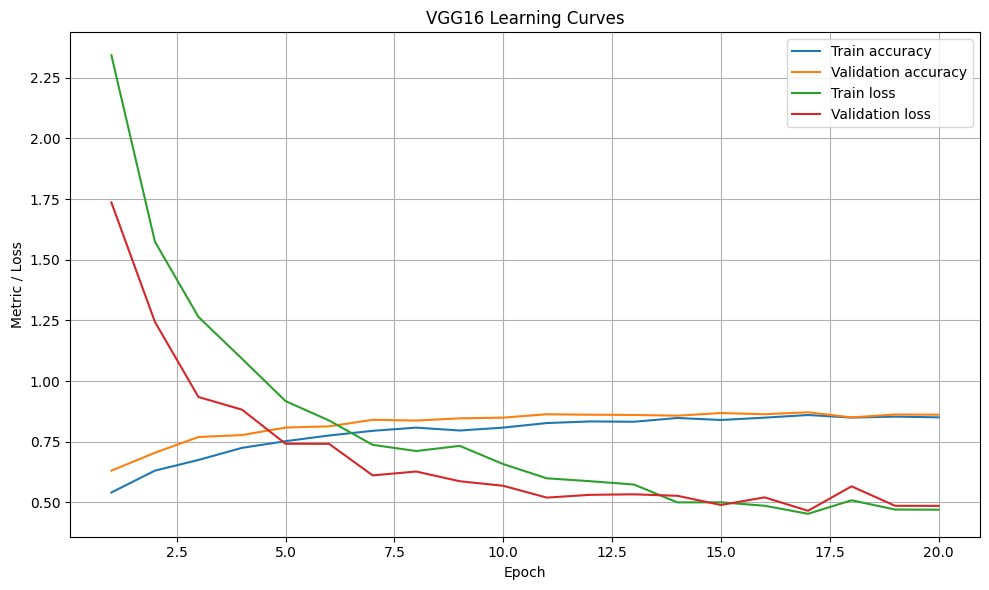

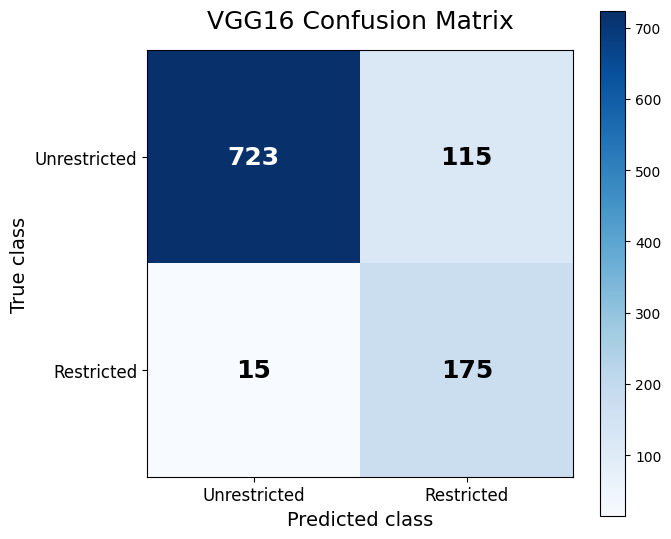


VGG16 confusion matrix as a table:


,Predicted unrestricted,Predicted restricted
True unrestricted,723,115
True restricted,15,175


Test metrics:


,threshold,accuracy,precision,recall,f1,mcc,tn,fp,fn,tp,auc,pr_auc,model,epochs_trained,input_height,input_width
0,0.5,0.8735,0.6034,0.9211,0.7292,0.6761,723,115,15,175,0.9467,0.8259,VGG16,20,224,224



TRAINING ResNet50
Input size: (224, 224)
Found 3023 files belonging to 2 classes.
Found 1002 files belonging to 2 classes.
Found 1028 files belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 parameters: 23,589,761
Epoch 1/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5502 - auc: 0.5607 - loss: 0.7585 - pr_auc: 0.2501 - precision: 0.2118 - recall: 0.4997
Epoch 1: val_loss improved from None to 0.51264, saving model to /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/ResNet50_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/ResNet50_best.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 40s 83ms/step - accuracy: 0.6513 - auc: 0.7001 - loss: 0.6408 - pr_auc: 0.3506 - precision: 0.2923 - recall: 0.6185 - val_accuracy: 0.7515 - val_auc: 0.8809 - val_loss: 0.5126 - val_pr_auc: 0.6692 - val_precision: 0.4169 - val_recall: 0.8495
Epoch 2/20
378/378 ━━━━━━━━━━━━━━━

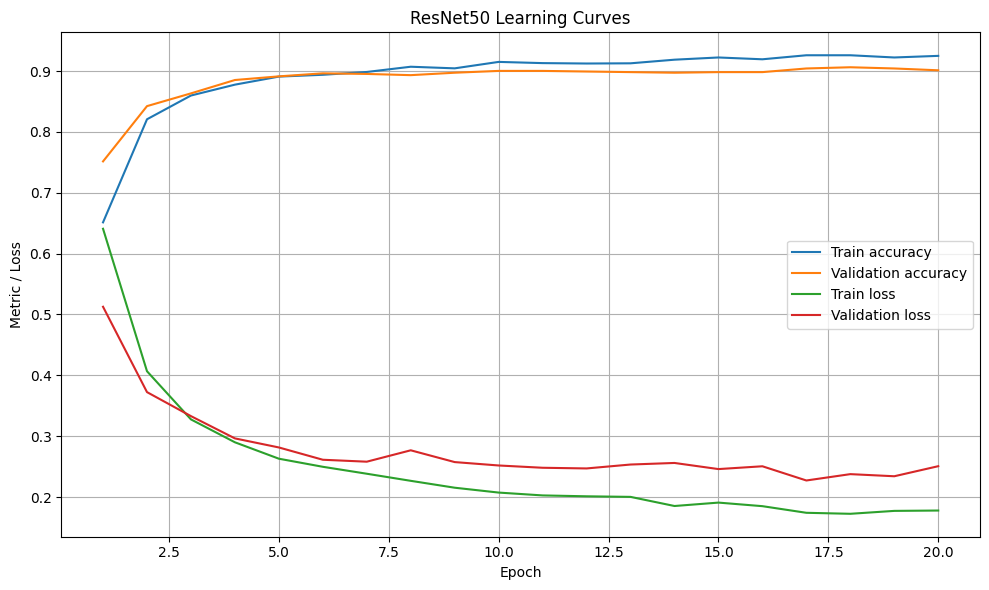

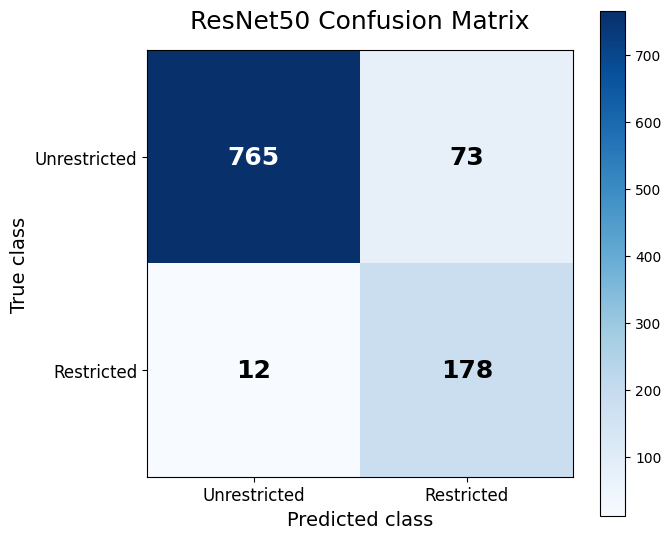


ResNet50 confusion matrix as a table:


,Predicted unrestricted,Predicted restricted
True unrestricted,765,73
True restricted,12,178


Test metrics:


,threshold,accuracy,precision,recall,f1,mcc,tn,fp,fn,tp,auc,pr_auc,model,epochs_trained,input_height,input_width
0,0.5,0.9173,0.7092,0.9368,0.8073,0.7678,765,73,12,178,0.9738,0.8986,ResNet50,20,224,224



TRAINING InceptionV3
Input size: (299, 299)
Found 3023 files belonging to 2 classes.
Found 1002 files belonging to 2 classes.
Found 1028 files belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
InceptionV3 parameters: 21,804,833
Epoch 1/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6882 - auc: 0.7471 - loss: 0.6098 - pr_auc: 0.4457 - precision: 0.3356 - recall: 0.6758
Epoch 1: val_loss improved from None to 0.42404, saving model to /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/InceptionV3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/InceptionV3_best.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 48s 99ms/step - accuracy: 0.7780 - auc: 0.8684 - loss: 0.5352 - pr_auc: 0.6233 - precision: 0.4462 - recall: 0.8128 - val_accuracy: 0.9152 - val_auc: 0.9751 - val_loss: 0.4240 - val_pr_auc: 0.8975 - val_precision: 0.6935 - val_recall: 0.9731
Epoch 2/20
378/378 ━━━

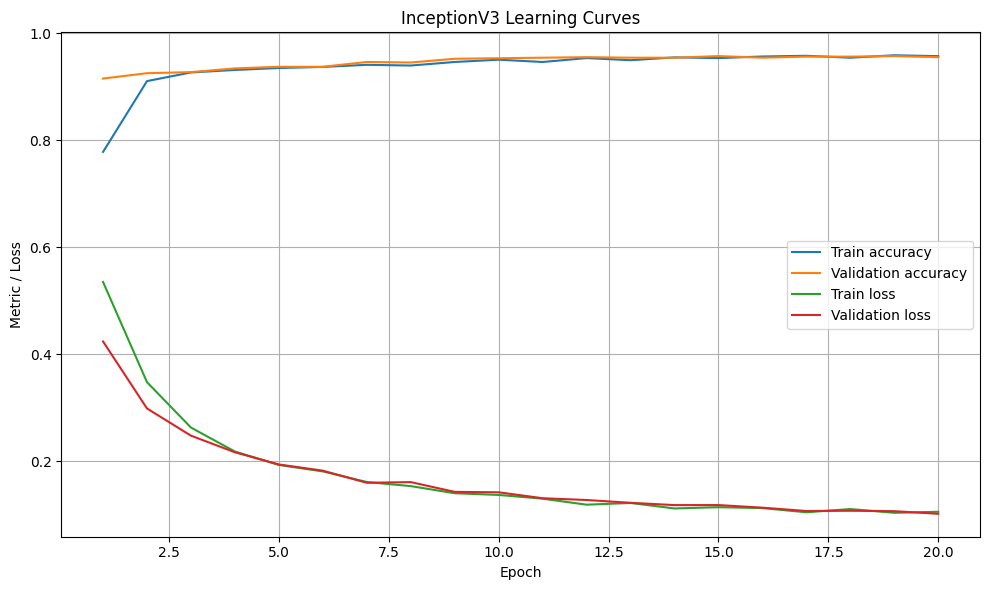

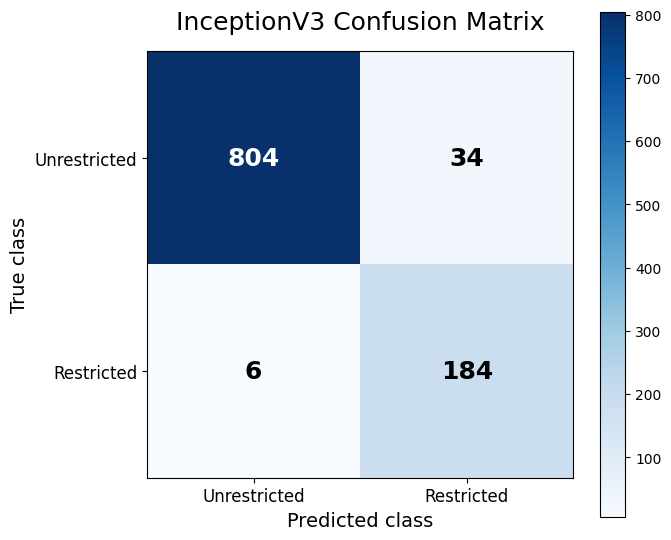


InceptionV3 confusion matrix as a table:


,Predicted unrestricted,Predicted restricted
True unrestricted,804,34
True restricted,6,184


Test metrics:


,threshold,accuracy,precision,recall,f1,mcc,tn,fp,fn,tp,auc,pr_auc,model,epochs_trained,input_height,input_width
0,0.5,0.9611,0.844,0.9684,0.902,0.8811,804,34,6,184,0.9935,0.9687,InceptionV3,20,299,299



TRAINING Xception
Input size: (299, 299)
Found 3023 files belonging to 2 classes.
Found 1002 files belonging to 2 classes.
Found 1028 files belonging to 2 classes.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Xception parameters: 20,863,529
Epoch 1/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8032 - auc: 0.8069 - loss: 0.6092 - pr_auc: 0.5575 - precision: 0.4715 - recall: 0.6037
Epoch 1: val_loss improved from None to 0.42529, saving model to /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/Xception_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/Xception_best.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 55s 128ms/step - accuracy: 0.8564 - auc: 0.9095 - loss: 0.5412 - pr_auc: 0.7288 - precision: 0.5848 - recall: 0.7807 - val_accuracy: 0.9261 - val_auc: 0.9734 - val_loss: 0.4253 - val_pr_auc: 0.8564 - val_precision: 0.7258 - val_recall: 0.9677
Epoch 2/20
378/378 ━━━━━━━━━━━━━━

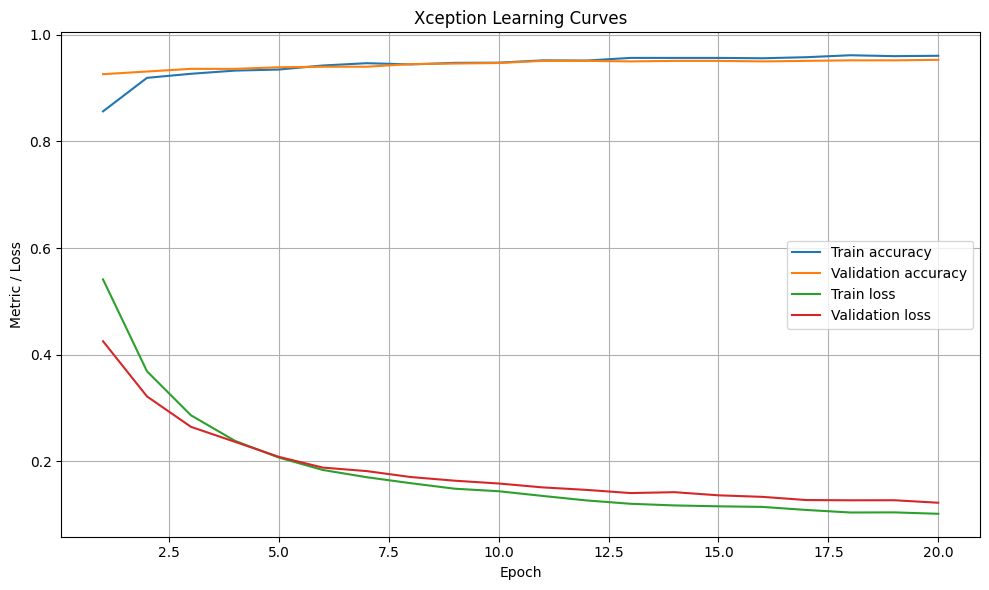

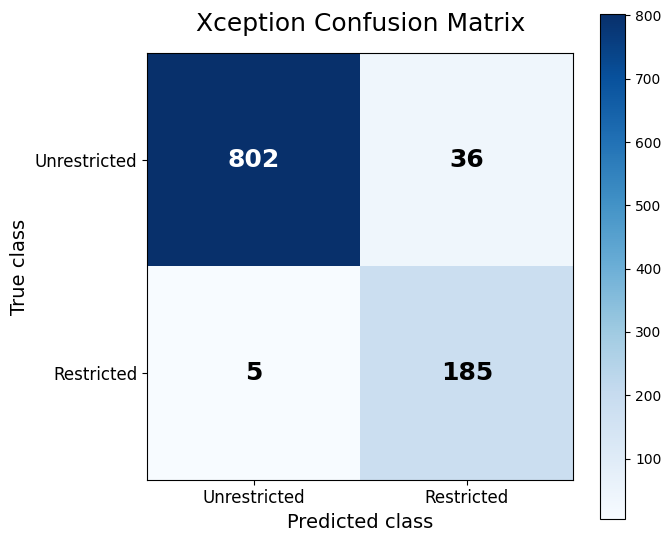


Xception confusion matrix as a table:


,Predicted unrestricted,Predicted restricted
True unrestricted,802,36
True restricted,5,185


Test metrics:


,threshold,accuracy,precision,recall,f1,mcc,tn,fp,fn,tp,auc,pr_auc,model,epochs_trained,input_height,input_width
0,0.5,0.9601,0.8371,0.9737,0.9002,0.8794,802,36,5,185,0.9939,0.9744,Xception,20,299,299



TRAINING InceptionResNetV2
Input size: (299, 299)
Found 3023 files belonging to 2 classes.
Found 1002 files belonging to 2 classes.
Found 1028 files belonging to 2 classes.
219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
InceptionResNetV2 parameters: 54,338,273
Epoch 1/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.5900 - auc: 0.7593 - loss: 0.6179 - pr_auc: 0.3992 - precision: 0.3107 - recall: 0.8564
Epoch 1: val_loss improved from None to 0.43689, saving model to /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/InceptionResNetV2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/InceptionResNetV2_best.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 101s 217ms/step - accuracy: 0.7595 - auc: 0.8889 - loss: 0.5409 - pr_auc: 0.6198 - precision: 0.4295 - recall: 0.9020 - val_accuracy: 0.9431 - val_auc: 0.9810 - val_loss: 0.4369 - val_pr_auc: 0.8775 - val_precision: 0.7745 - val_recall: 

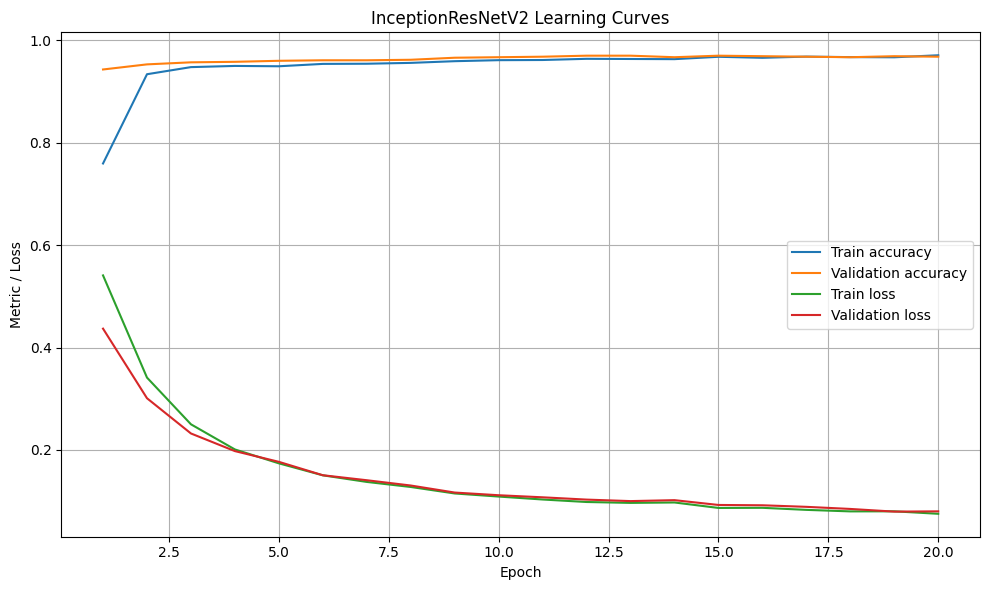

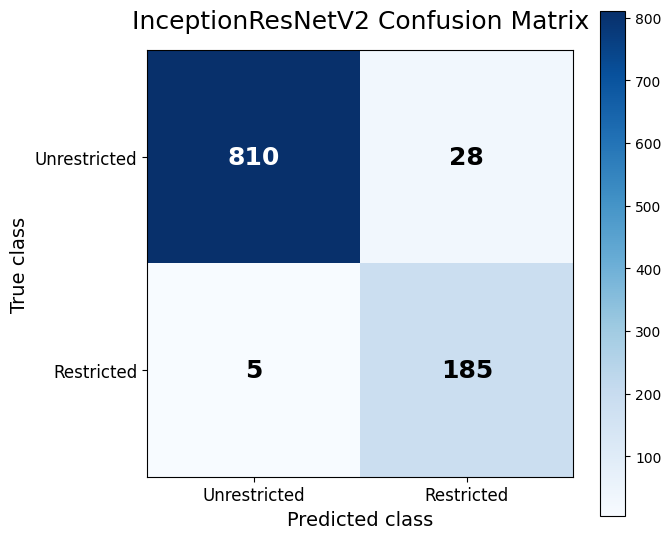


InceptionResNetV2 confusion matrix as a table:


,Predicted unrestricted,Predicted restricted
True unrestricted,810,28
True restricted,5,185


Test metrics:


,threshold,accuracy,precision,recall,f1,mcc,tn,fp,fn,tp,auc,pr_auc,model,epochs_trained,input_height,input_width
0,0.5,0.9679,0.8685,0.9737,0.9181,0.9005,810,28,5,185,0.9968,0.9872,InceptionResNetV2,20,299,299



TRAINING NASNetMobile
Input size: (224, 224)
Found 3023 files belonging to 2 classes.
Found 1002 files belonging to 2 classes.
Found 1028 files belonging to 2 classes.
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
NASNetMobile parameters: 4,270,773
Epoch 1/20
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5850 - auc: 0.7287 - loss: 0.6223 - pr_auc: 0.3540 - precision: 0.2901 - recall: 0.7807
Epoch 1: val_loss improved from None to 0.41472, saving model to /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/NASNetMobile_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/NASNetMobile_best.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 67s 122ms/step - accuracy: 0.7106 - auc: 0.8152 - loss: 0.5481 - pr_auc: 0.4598 - precision: 0.3705 - recall: 0.8004 - val_accuracy: 0.8693 - val_auc: 0.9530 - val_loss: 0.4147 - val_pr_auc: 0.7662 - val_precision: 0.5926 - val_recall: 0.9462
Epoch 2/20
377/378

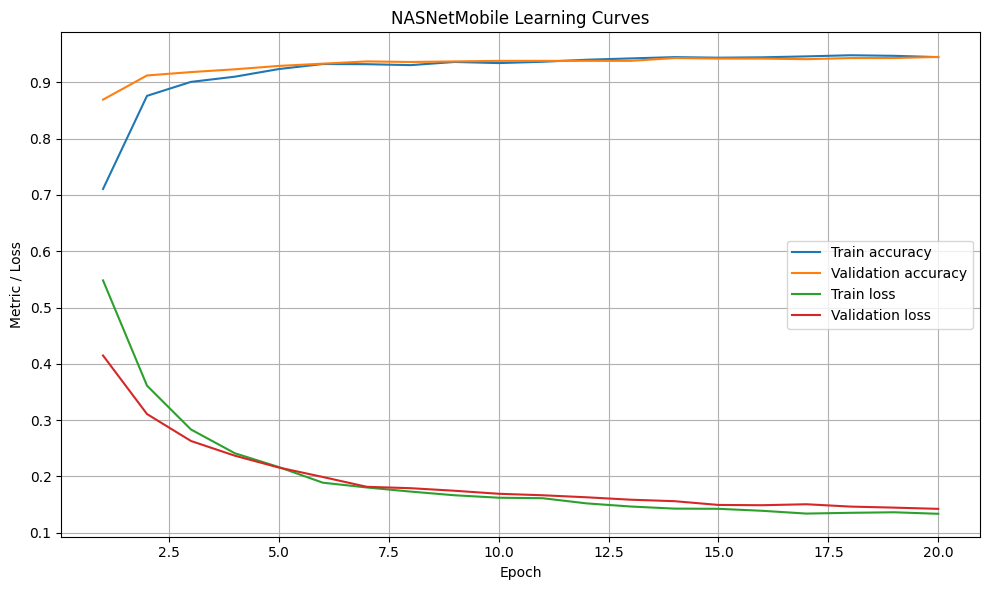

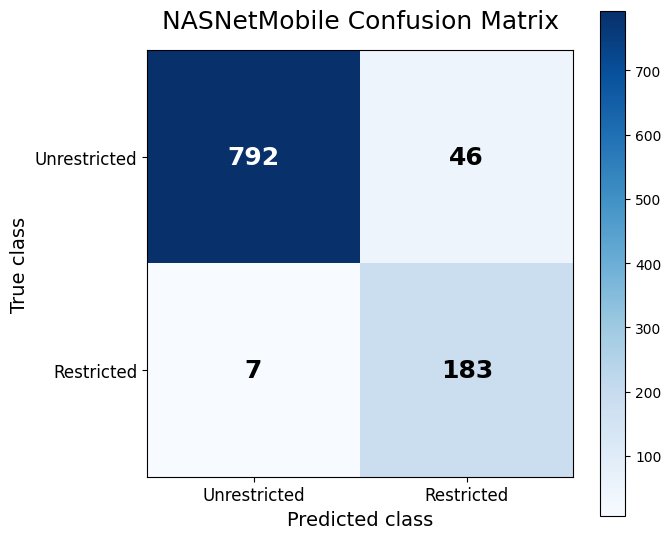


NASNetMobile confusion matrix as a table:


,Predicted unrestricted,Predicted restricted
True unrestricted,792,46
True restricted,7,183


Test metrics:


,threshold,accuracy,precision,recall,f1,mcc,tn,fp,fn,tp,auc,pr_auc,model,epochs_trained,input_height,input_width
0,0.5,0.9484,0.7991,0.9632,0.8735,0.8473,792,46,7,183,0.988,0.9526,NASNetMobile,20,224,224



All requested models have either finished or been skipped.


In [ ]:
# ============================================================
# 10. Train the model zoo safely, skipping completed models
# ============================================================

results_path = LOG_DIR / "model_zoo_results_partial.csv"

if results_path.exists():
    all_results = pd.read_csv(results_path).to_dict("records")
    completed_models = set(pd.read_csv(results_path)["model"].tolist())
    print("Loaded existing results:")
    print(sorted(completed_models))
else:
    all_results = []
    completed_models = set()
    print("No previous results file found. Starting fresh.")

for model_name in TO_RUN:

    checkpoint_path = CHECKPOINT_DIR / f"{model_name}_best.keras"
    history_path = LOG_DIR / f"{model_name}_history.json"
    prediction_path = PREDICTION_DIR / f"{model_name}_test_predictions.csv"
    confusion_path = FIGURE_DIR / f"{model_name}_confusion_matrix.png"
    curve_path = FIGURE_DIR / f"{model_name}_learning_curves.png"

    already_done = (
        model_name in completed_models
        and checkpoint_path.exists()
        and history_path.exists()
        and prediction_path.exists()
        and confusion_path.exists()
        and curve_path.exists()
    )

    if already_done:
        print("\n" + "=" * 70)
        print("SKIPPING", model_name)
        print("Already trained and logged.")
        print("=" * 70)
        continue

    print("\n" + "=" * 70)
    print("TRAINING", model_name)
    print("=" * 70)

    input_size = MODEL_ZOO[model_name]["input_size"]
    print("Input size:", input_size)

    train_ds, val_ds, test_ds = make_datasets(input_size)
    model = build_frozen_model(model_name)

    print(model_name, "parameters:", f"{model.count_params():,}")

    history_obj = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=make_callbacks(model_name),
        class_weight=CLASS_WEIGHT,
        verbose=1,
    )

    history = history_obj.history

    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)

    save_learning_curve(history, model_name)

    best_path = CHECKPOINT_DIR / f"{model_name}_best.keras"
    if best_path.exists():
        model = tf.keras.models.load_model(best_path)

    y_true, y_prob = collect_predictions(model, test_ds)
    metrics = compute_metrics(y_true, y_prob, threshold=THRESHOLD)

    metrics["model"] = model_name
    metrics["epochs_trained"] = len(history["loss"])
    metrics["input_height"] = input_size[0]
    metrics["input_width"] = input_size[1]

    all_results.append(metrics)

    pred_df = pd.DataFrame({
        "y_true": y_true,
        "y_probability_restricted": y_prob,
        "y_pred": (y_prob >= THRESHOLD).astype(int),
    })

    pred_df.to_csv(prediction_path, index=False)

    save_confusion_matrix_plot(y_true, y_prob, model_name, threshold=THRESHOLD)

    results_df = pd.DataFrame(all_results)
    results_df = results_df.drop_duplicates(subset=["model"], keep="last")
    results_df.to_csv(results_path, index=False)

    print("Test metrics:")
    display(pd.DataFrame([metrics]).round(4))

    del model, train_ds, val_ds, test_ds, history_obj
    gc.collect()
    tf.keras.backend.clear_session()

print("\nAll requested models have either finished or been skipped.")


In [ ]:
# ============================================================
# 11. Save and display final model comparison
# ============================================================
results_df = pd.DataFrame(all_results)

if results_df.empty:
    raise RuntimeError("No model results were produced. Check the training cell above.")

# Put the most useful columns first.
preferred_cols = [
    "model", "accuracy", "precision", "recall", "f1", "auc", "pr_auc", "mcc",
    "tn", "fp", "fn", "tp", "epochs_trained", "threshold", "input_height", "input_width",
]
ordered_cols = [c for c in preferred_cols if c in results_df.columns] + [
    c for c in results_df.columns if c not in preferred_cols
]
results_df = results_df[ordered_cols]

results_csv = LOG_DIR / "model_zoo_results.csv"
results_json = LOG_DIR / "model_zoo_results.json"
results_df.to_csv(results_csv, index=False)
results_df.to_json(results_json, orient="records", indent=2)

print("Final model comparison:")
display(results_df.round(4))

print("Saved CSV: ", results_csv)
print("Saved JSON:", results_json)
print("Saved checkpoints:", CHECKPOINT_DIR)
print("Saved figures:    ", FIGURE_DIR)
print("Saved predictions:", PREDICTION_DIR)


Final model comparison:


,model,accuracy,precision,recall,f1,auc,pr_auc,mcc,tn,fp,fn,tp,epochs_trained,threshold,input_height,input_width
0,VGG16,0.8735,0.6034,0.9211,0.7292,0.9467,0.8259,0.6761,723,115,15,175,20,0.5,224,224
1,ResNet50,0.9173,0.7092,0.9368,0.8073,0.9738,0.8986,0.7678,765,73,12,178,20,0.5,224,224
2,InceptionV3,0.9611,0.8440,0.9684,0.9020,0.9935,0.9687,0.8811,804,34,6,184,20,0.5,299,299
3,Xception,0.9601,0.8371,0.9737,0.9002,0.9939,0.9744,0.8794,802,36,5,185,20,0.5,299,299
4,InceptionResNetV2,0.9679,0.8685,0.9737,0.9181,0.9968,0.9872,0.9005,810,28,5,185,20,0.5,299,299
5,NASNetMobile,0.9484,0.7991,0.9632,0.8735,0.9880,0.9526,0.8473,792,46,7,183,20,0.5,224,224


Saved CSV:  /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/logs/model_zoo_results.csv
Saved JSON: /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/logs/model_zoo_results.json
Saved checkpoints: /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints
Saved figures:     /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/figures
Saved predictions: /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/predictions


In [ ]:
# ============================================================
# 12. Select a suggested winner for Notebook 3
# ============================================================
# The project is about restricted-breed detection, so recall matters because
# false negatives mean restricted dogs missed by the classifier.
# This ranking prioritises recall, then PR-AUC, then F1.

ranking_cols = ["recall", "pr_auc", "f1", "precision", "accuracy"]
existing_ranking_cols = [c for c in ranking_cols if c in results_df.columns]

ranked = results_df.sort_values(existing_ranking_cols, ascending=False).reset_index(drop=True)

print("Suggested ranking for fine-tuning:")
display(ranked[["model"] + existing_ranking_cols].round(4))

winner = ranked.loc[0, "model"]

winner_path = LOG_DIR / "suggested_winner.txt"
with open(winner_path, "w") as f:
    f.write(str(winner))

print("Suggested Notebook 3 starting model:", winner)
print("Saved suggestion to:", winner_path)
print("Notebook 2 complete.")


Suggested ranking for fine-tuning:


,model,recall,pr_auc,f1,precision,accuracy
0,InceptionResNetV2,0.9737,0.9872,0.9181,0.8685,0.9679
1,Xception,0.9737,0.9744,0.9002,0.8371,0.9601
2,InceptionV3,0.9684,0.9687,0.9020,0.8440,0.9611
3,NASNetMobile,0.9632,0.9526,0.8735,0.7991,0.9484
4,ResNet50,0.9368,0.8986,0.8073,0.7092,0.9173
5,VGG16,0.9211,0.8259,0.7292,0.6034,0.8735


Suggested Notebook 3 starting model: InceptionResNetV2
Saved suggestion to: /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/logs/suggested_winner.txt
Notebook 2 complete.


Regenerating confusion matrices...

Updating: VGG16


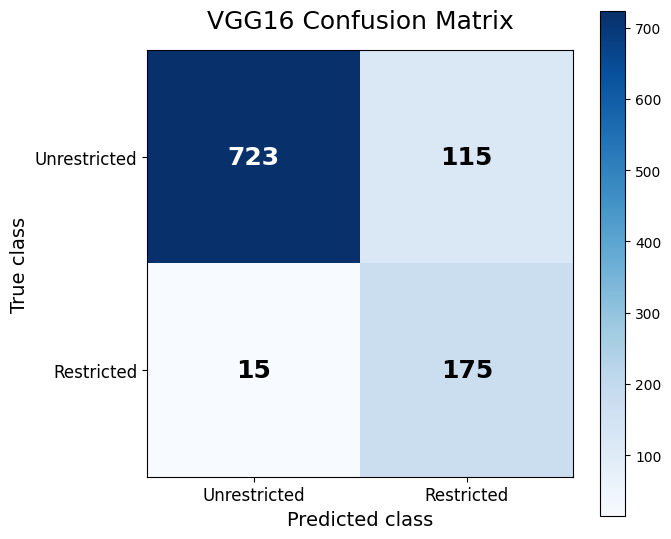


VGG16 confusion matrix as a table:


,Predicted unrestricted,Predicted restricted
True unrestricted,723,115
True restricted,15,175


Saved: /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/figures/VGG16_confusion_matrix.png

Updating: ResNet50


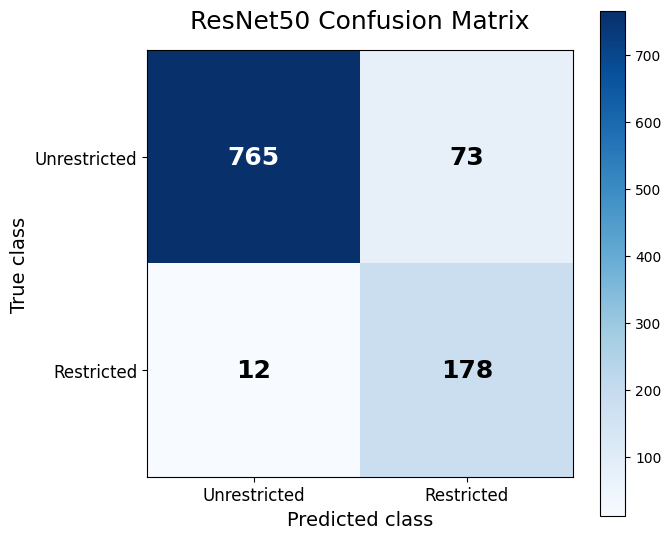


ResNet50 confusion matrix as a table:


,Predicted unrestricted,Predicted restricted
True unrestricted,765,73
True restricted,12,178


Saved: /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/figures/ResNet50_confusion_matrix.png

Updating: InceptionV3


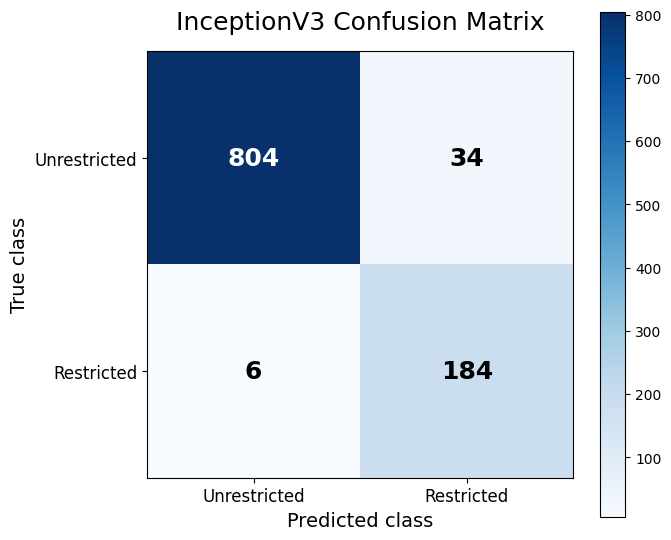


InceptionV3 confusion matrix as a table:


,Predicted unrestricted,Predicted restricted
True unrestricted,804,34
True restricted,6,184


Saved: /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/figures/InceptionV3_confusion_matrix.png

Updating: Xception


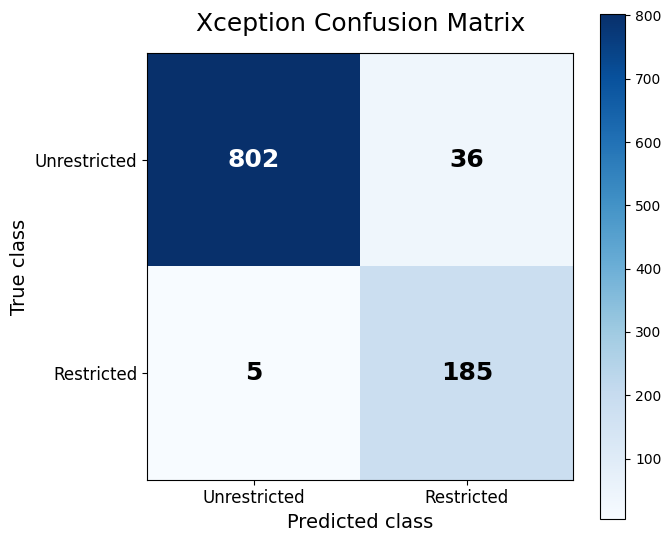


Xception confusion matrix as a table:


,Predicted unrestricted,Predicted restricted
True unrestricted,802,36
True restricted,5,185


Saved: /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/figures/Xception_confusion_matrix.png

Updating: InceptionResNetV2


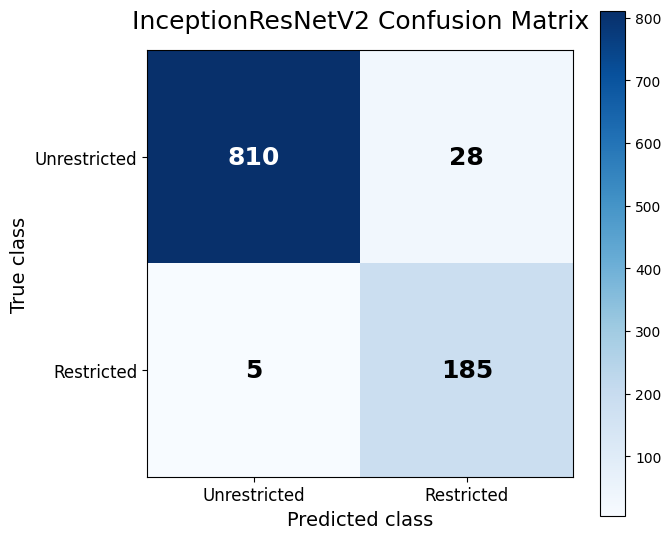


InceptionResNetV2 confusion matrix as a table:


,Predicted unrestricted,Predicted restricted
True unrestricted,810,28
True restricted,5,185


Saved: /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/figures/InceptionResNetV2_confusion_matrix.png

Updating: NASNetMobile


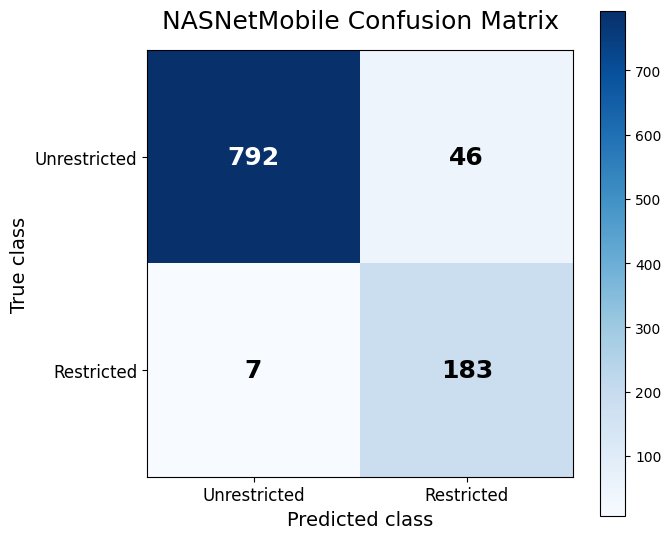


NASNetMobile confusion matrix as a table:


,Predicted unrestricted,Predicted restricted
True unrestricted,792,46
True restricted,7,183


Saved: /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/figures/NASNetMobile_confusion_matrix.png

All confusion matrices regenerated.


In [ ]:
# ============================================================
# 13. Regenerate confusion matrices from saved prediction CSVs
# ============================================================

print("Regenerating confusion matrices...")

for model_name in TO_RUN:

    print("\n" + "=" * 70)
    print("Updating:", model_name)
    print("=" * 70)

    pred_path = (
        PREDICTION_DIR
        / f"{model_name}_test_predictions.csv"
    )

    if not pred_path.exists():
        print("Prediction CSV missing.")
        continue

    pred_df = pd.read_csv(pred_path)

    y_true = pred_df["y_true"].values

    y_prob = pred_df[
        "y_probability_restricted"
    ].values

    out_path = save_confusion_matrix_plot(
        y_true,
        y_prob,
        model_name,
        threshold=THRESHOLD,
    )

    print("Saved:", out_path)

print("\nAll confusion matrices regenerated.")

# Presentation figures

The following cells use the saved benchmark results only. They do **not** retrain any model.

Run the project-path cell first, then run these cells to regenerate:

- a clean six-model results table;
- a full-width grouped comparison chart;
- large values above every bar;
- PNG and PDF versions for the viva slides.


In [1]:
# ============================================================
# 14. Load saved frozen-model benchmark results
#    Presentation-only cell: no retraining
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results_csv = LOG_DIR / "model_zoo_results.csv"

if not results_csv.exists():
    raise FileNotFoundError(
        f"Saved benchmark results were not found at: {results_csv}\n"
        "Run the final comparison cell in Notebook 2 first."
    )

presentation_results = pd.read_csv(results_csv)

required_columns = [
    "model", "accuracy", "precision", "recall", "f1"
]

missing_columns = [
    column for column in required_columns
    if column not in presentation_results.columns
]

if missing_columns:
    raise ValueError(
        "The results file is missing required columns: "
        + ", ".join(missing_columns)
    )

model_order = [
    "VGG16",
    "ResNet50",
    "InceptionV3",
    "Xception",
    "InceptionResNetV2",
    "NASNetMobile",
]

presentation_results["model"] = pd.Categorical(
    presentation_results["model"],
    categories=model_order,
    ordered=True,
)

presentation_results = (
    presentation_results
    .sort_values("model")
    .reset_index(drop=True)
)

display_columns = [
    "model", "accuracy", "precision", "recall", "f1",
    "pr_auc", "mcc", "fp", "fn"
]

display_columns = [
    column for column in display_columns
    if column in presentation_results.columns
]

presentation_table = presentation_results[display_columns].copy()

for column in ["accuracy", "precision", "recall", "f1"]:
    if column in presentation_table.columns:
        presentation_table[column] = (
            presentation_table[column] * 100
        ).round(2)

for column in ["pr_auc", "mcc"]:
    if column in presentation_table.columns:
        presentation_table[column] = presentation_table[column].round(4)

print("Frozen-model benchmark results for presentation")
display(presentation_table)

presentation_table_csv = (
    FIGURE_DIR / "frozen_model_results_presentation.csv"
)

presentation_table.to_csv(presentation_table_csv, index=False)
print("Saved presentation table:", presentation_table_csv)


NameError: name 'LOG_DIR' is not defined

In [ ]:
# ============================================================
# 15. Full-width grouped bar chart for viva slides
#    Large labels above each bar
# ============================================================
metric_columns = ["accuracy", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1"]

chart_data = presentation_results.copy()

for column in metric_columns:
    chart_data[column] = chart_data[column] * 100

x = np.arange(len(chart_data))
bar_width = 0.19

fig, ax = plt.subplots(figsize=(18, 9))

for metric_index, (column, label) in enumerate(
    zip(metric_columns, metric_labels)
):
    offset = (metric_index - 1.5) * bar_width

    bars = ax.bar(
        x + offset,
        chart_data[column],
        width=bar_width,
        label=label,
    )

    ax.bar_label(
        bars,
        labels=[f"{value:.1f}" for value in chart_data[column]],
        padding=4,
        fontsize=15,
        fontweight="bold",
    )

ax.set_xticks(x)
ax.set_xticklabels(
    chart_data["model"].astype(str),
    fontsize=16,
)

ax.set_ylabel("Test performance (%)", fontsize=18)
ax.tick_params(axis="y", labelsize=15)

# The truncated axis improves readability because all models score highly.
# It is explicitly labelled and should be mentioned when presenting.
ax.set_ylim(70, 103)
ax.set_yticks(np.arange(70, 101, 5))

ax.legend(
    fontsize=15,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    frameon=False,
)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

png_path = FIGURE_DIR / "model_zoo_four_metric_comparison_presentation.png"
pdf_path = FIGURE_DIR / "model_zoo_four_metric_comparison_presentation.pdf"

fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")

plt.show()
plt.close(fig)

print("Saved presentation chart:", png_path)
print("Saved vector chart:      ", pdf_path)


In [ ]:
# ============================================================
# 16. Optional: compact slide table as a figure
# ============================================================
slide_table = presentation_table[
    ["model", "accuracy", "precision", "recall", "f1"]
].copy()

slide_table.columns = [
    "Model", "Accuracy", "Precision", "Recall", "F1"
]

fig, ax = plt.subplots(figsize=(14, 5.8))
ax.axis("off")

table_text = slide_table.copy()

for column in ["Accuracy", "Precision", "Recall", "F1"]:
    table_text[column] = table_text[column].map(lambda value: f"{value:.2f}%")

table = ax.table(
    cellText=table_text.values,
    colLabels=table_text.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1.0, 2.0)

for (row, column), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
    if row > 0 and table_text.iloc[row - 1, 0] == "InceptionResNetV2":
        cell.set_text_props(weight="bold")

fig.tight_layout()

table_png = FIGURE_DIR / "frozen_model_results_table_presentation.png"
table_pdf = FIGURE_DIR / "frozen_model_results_table_presentation.pdf"

fig.savefig(table_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(table_pdf, bbox_inches="tight", facecolor="white")

plt.show()
plt.close(fig)

print("Saved table image:", table_png)
print("Saved table PDF:  ", table_pdf)
